# Modelo - InceptionResNetV2

Juan Muelledes Mateos - Trabajo final de Modelado Computacional, Simulacion y Optimización

25-03-2026 - Prueba del modelo InceptionResNetV2 con modulos CASA empleando también Aumentado offline fuerte, Pesos ponderados suavizados, Focal Loss, Mixup, y entrenamiento de dos fases. Precisión a superar: 91,9%. Precision obtenida 91,5%. Estos cambios no empeoran el modelo pero no lo mejoran.

30-03-2026 - Finetuning del entrenamiento de backbone fase 2

Para mañana - Finetuning con cambios de Gamma y Alpha. Mixup alpha 0.4  Focal Gamma 3.0 y en finetuning congelar 200 primeras en vez de 250.

Hoy, Viernes Santo: Probar con

## 1. Importamos las librerias necesarias

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import itertools
import sklearn
from sklearn.metrics import classification_report
from tensorflow.keras.applications import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input as base_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.regularizers import l2

## 2. Cargamos las imagenes y las etiquetas

In [ ]:
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/Archivos Modelado/data.npy')
labels = np.load('/content/drive/MyDrive/Archivos Modelado/labels.npy')

Mounted at /content/drive


In [ ]:
def random_rotation(img, angle_range=20):
    angle = np.random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          borderMode=cv2.BORDER_REFLECT_101)
def random_brightness_contrast(img):
    alpha = np.random.uniform(0.8, 1.2)  # contraste
    beta = np.random.uniform(-25, 25)    # brillo
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def add_gaussian_noise(img):
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_zoom(img, zoom_range=(0.9, 1.1)):
    h, w = img.shape[:2]
    scale = np.random.uniform(*zoom_range)

    new_h, new_w = int(h*scale), int(w*scale)
    resized = cv2.resize(img, (new_w, new_h))

    if scale > 1:
        startx = (new_w - w)//2
        starty = (new_h - h)//2
        return resized[starty:starty+h, startx:startx+w]
    else:
        pad_h = (h - new_h)//2
        pad_w = (w - new_w)//2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_REFLECT_101
        )
def random_blur(img):
    k = np.random.choice([3,5])
    return cv2.GaussianBlur(img, (k,k), 0)

In [ ]:
def produce_new_img_strong(img):

    augmented = []

    # --- tus originales ---
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_180))
    augmented.append(cv2.flip(img, 0))
    augmented.append(cv2.flip(img, 1))

    # --- NUEVAS ---
    augmented.append(random_rotation(img))
    augmented.append(random_brightness_contrast(img))
    augmented.append(add_gaussian_noise(img))
    augmented.append(random_zoom(img))
    augmented.append(random_blur(img))

    return augmented

In [ ]:
import cv2
from cv2 import imread, resize

def apply_augmentation_to_minority_classes(X_train, y_train_one_hot):
    augmented_images = []
    augmented_labels = []

    # Convertir one-hot a índices
    y_train_indices = np.argmax(y_train_one_hot, axis=1)

    for img, label_idx in zip(X_train, y_train_indices):
        augmented_images.append(img)
        augmented_labels.append(label_idx)

        if label_idx != 5 and label_idx != 2 and label_idx != 4:  # Después de ordenar, 5 es NV, la clase matyoritaria
            new_imgs = produce_new_img_strong(img)
            for new_img in new_imgs:
                augmented_images.append(new_img)
                augmented_labels.append(label_idx)

    # Convertir las etiquetas aumentadas a one-hot
    augmented_labels_one_hot = to_categorical(augmented_labels, num_classes=7)
    return np.array(augmented_images), augmented_labels_one_hot

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.1, stratify=labels, random_state=42
)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.111, stratify=train_labels, random_state=42
)

train_data, train_labels = apply_augmentation_to_minority_classes(train_data, train_labels)

print("Rango de valores en train_data:", train_data.min(), train_data.max())

train_data = (train_data / 127.5) - 1.0
val_data = (val_data / 127.5) - 1.0
test_data = (test_data / 127.5) - 1.0

print("Rango de valores en train_data:", train_data.min(), train_data.max())

Rango de valores en train_data: 0 255
Rango de valores en train_data: -1.0 1.0


## 3. Dividimos los datos a conjuntos de entrenamiento, validación y test

In [ ]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (16792, 224, 224, 3)
train_labels shape: (16792, 7)
val_data shape: (1001, 224, 224, 3)
val_labels shape: (1001, 7)
test_data shape: (1002, 224, 224, 3)
test_labels shape: (1002, 7)


In [ ]:
class_names_mapping = {
    0: "AKIEC",
    1: "BCC",
    2: "BKL",
    3: "DF",
    4: "MEL",
    5: "NV",
    6: "VASC"
}

num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {count}")

y_train_integers = np.argmax(train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = {i: np.sqrt(w) for i, w in class_weight_dict.items()}

print("\n Pesos para cada clase para paliar desbalance:")
for cls, weight in class_weight_dict.items():
    print(f"Class {class_names_mapping[cls]}: {weight:.4f}")

AKIEC
 - Train: 2871.0
 - Validation: 33.0
 - Test: 33.0
BCC
 - Train: 4532.0
 - Validation: 51.0
 - Test: 51.0
BKL
 - Train: 879.0
 - Validation: 110.0
 - Test: 110.0
DF
 - Train: 1001.0
 - Validation: 12.0
 - Test: 12.0
MEL
 - Train: 891.0
 - Validation: 111.0
 - Test: 111.0
NV
 - Train: 5364.0
 - Validation: 670.0
 - Test: 671.0
VASC
 - Train: 1254.0
 - Validation: 14.0
 - Test: 14.0

 Pesos para cada clase para paliar desbalance:
Class AKIEC: 0.9141
Class BCC: 0.7275
Class BKL: 1.6520
Class DF: 1.5481
Class MEL: 1.6408
Class NV: 0.6687
Class VASC: 1.3831


## 4. Definimos los elementos necesarios para el entrenamiento

### 4.1 Generador de datos aumentados

In [ ]:
alpha_list = [class_weight_dict[i] for i in range(num_classes)]

batch_size = 16

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
class MixupSequence(tf.keras.utils.Sequence):
    def __init__(self, x, y, batch_size, datagen, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.datagen = datagen
        self.alpha = alpha
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.x[batch_indices].copy()
        batch_y = self.y[batch_indices].copy()

        # Aplicar transformaciones aleatorias a cada imagen
        for i in range(len(batch_x)):
            batch_x[i] = self.datagen.random_transform(batch_x[i])

        # Mezclar con MixUp
        lam = np.random.beta(self.alpha, self.alpha)
        idx_perm = np.random.permutation(len(batch_x))
        mixed_x = lam * batch_x + (1 - lam) * batch_x[idx_perm]
        mixed_y = lam * batch_y + (1 - lam) * batch_y[idx_perm]
        return mixed_x, mixed_y

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,
                          alpha=0.4)

### 4.2 Funciones de Callback

In [ ]:
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience = 5,mode='max', min_lr = 1e-5,verbose = 1)
saved_model = '/content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5'
model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)
early_stop = EarlyStopping(monitor = 'val_accuracy', min_delta = 0.001, patience = 10, verbose = 1)

callback_list = [model_chkpt, lr_reduce, early_stop]

### 4.3 Modelo InceptionResNetV2

In [ ]:
def channel_attention(input_tensor, reduction_ratio=16):

    avg_pool = GlobalAveragePooling2D()(input_tensor)
    max_pool = GlobalMaxPooling2D()(input_tensor)

    def shared_mlp(x):
        x = Dense(input_tensor.shape[-1] // reduction_ratio, activation='relu')(x)
        x = Dense(input_tensor.shape[-1], activation='sigmoid')(x)
        return x

    avg_att = shared_mlp(avg_pool)
    max_att = shared_mlp(max_pool)
    attention = Add()([avg_att, max_att])
    attention = Activation('sigmoid')(attention)

    attention = Reshape((1, 1, input_tensor.shape[-1]))(attention)
    attended_features = Multiply()([input_tensor, attention])
    return attended_features

def spatial_attention(input_tensor, kernel_size=7):

    # Promedio a través del canal (keepdims=True para mantener forma espacial)
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_tensor)
    # Máximo a través del canal
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_tensor)

    # Concatenar a lo largo del canal (ahora shape: [batch, H, W, 2])
    concat = Concatenate(axis=-1)([avg_pool, max_pool])

    # Convolución 7x7 con 1 filtro, activación sigmoide
    attention = Conv2D(1, kernel_size, padding='same', activation='sigmoid')(concat)

    attended_features = Multiply()([input_tensor, attention])
    return attended_features

def casa_module(input_tensor, reduction_ratio=16, spatial_kernel=7):

    channel_att = channel_attention(input_tensor, reduction_ratio)
    spatial_att = spatial_attention(input_tensor, spatial_kernel)
    combined_att = Add()([channel_att, spatial_att])
    output = Add()([input_tensor, combined_att])
    return output

In [ ]:
base_model = InceptionResNetV2(weights='imagenet',
                        include_top=False,
                        input_shape=(224, 224, 3))

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


### 4.4 Modificación de la red InceptionResNetV2 y compilación

In [ ]:
dropout_rate = 0.5

x = base_model.output
x = casa_module(x)

x = GlobalAveragePooling2D()(x)
x = Dense(512, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate)(x)

x = Dense(256, kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(dropout_rate * 0.8)(x)


predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = CategoricalFocalCrossentropy(alpha=alpha_list, gamma=2.0)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

## 5. Entrenamos el modelo

In [ ]:
epochs = 50

In [ ]:
history = model.fit(train_gen,
                    validation_data=(val_data, val_labels),
                    epochs=epochs,
                    callbacks=callback_list,
                    class_weight = class_weight_dict)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3695 - loss: 1.4774
Epoch 1: val_accuracy improved from None to 0.59141, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 492s 315ms/step - accuracy: 0.4693 - loss: 1.2061 - val_accuracy: 0.5914 - val_loss: 0.6327 - learning_rate: 1.0000e-04
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6135 - loss: 0.8897
Epoch 2: val_accuracy improved from 0.59141 to 0.62238, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 225s 214ms/step - accuracy: 0.6286 - loss: 0.8568 - val_accuracy: 0.6224 - val_loss: 0.5585 - learning_rate: 1.0000e-04
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6634 - loss: 0.8099
Epoch 3: val_accuracy improved from 0.62238 to 0.65934, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5



Epoch 3: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 223s 212ms/step - accuracy: 0.6738 - loss: 0.7938 - val_accuracy: 0.6593 - val_loss: 0.6664 - learning_rate: 1.0000e-04
Epoch 4/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7104 - loss: 0.7520
Epoch 4: val_accuracy improved from 0.65934 to 0.66533, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5


...


Epoch 24: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 217s 207ms/step - accuracy: 0.8989 - loss: 0.3925 - val_accuracy: 0.8701 - val_loss: 0.2720 - learning_rate: 5.0000e-05
Epoch 25/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9057 - loss: 0.4095
Epoch 25: val_accuracy did not improve from 0.87013
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 209s 199ms/step - accuracy: 0.9070 - loss: 0.3918 - val_accuracy: 0.8681 - val_loss: 0.2739 - learning_rate: 5.0000e-05
Epoch 26/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9039 - loss: 0.3703
Epoch 26: val_accuracy did not improve from 0.87013
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 201s 191ms/step - accuracy: 0.9060 - loss: 0.3803 - val_accuracy: 0.8611 - val_loss: 0.2870 - learning_rate: 5.0000e-05
Epoch 27/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9090 - loss: 0.3866
Epoch 27: val_accuracy did not improve from 0.87013
1050


Epoch 29: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 221s 211ms/step - accuracy: 0.9094 - loss: 0.3656 - val_accuracy: 0.8751 - val_loss: 0.2911 - learning_rate: 5.0000e-05
Epoch 30/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9075 - loss: 0.3860
Epoch 30: val_accuracy did not improve from 0.87512
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 200s 190ms/step - accuracy: 0.9064 - loss: 0.3861 - val_accuracy: 0.8701 - val_loss: 0.3160 - learning_rate: 5.0000e-05
Epoch 31/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9096 - loss: 0.3715
Epoch 31: val_accuracy did not improve from 0.87512
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 204s 194ms/step - accuracy: 0.9069 - loss: 0.3755 - val_accuracy: 0.8302 - val_loss: 0.3216 - learning_rate: 5.0000e-05
Epoch 32/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9110 - loss: 0.3519
Epoch 32: val_accuracy did not improve from 0.87512
1050


Epoch 36: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 223s 212ms/step - accuracy: 0.9199 - loss: 0.3397 - val_accuracy: 0.8791 - val_loss: 0.2583 - learning_rate: 2.5000e-05
Epoch 37/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9277 - loss: 0.3163
Epoch 37: val_accuracy did not improve from 0.87912
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 205s 195ms/step - accuracy: 0.9259 - loss: 0.3255 - val_accuracy: 0.8432 - val_loss: 0.2817 - learning_rate: 2.5000e-05
Epoch 38/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9228 - loss: 0.3256
Epoch 38: val_accuracy did not improve from 0.87912
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 206s 196ms/step - accuracy: 0.9235 - loss: 0.3287 - val_accuracy: 0.8731 - val_loss: 0.2713 - learning_rate: 2.5000e-05
Epoch 39/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9226 - loss: 0.3452
Epoch 39: val_accuracy improved from 0.87912 to 0.88711,


Epoch 39: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 219s 208ms/step - accuracy: 0.9189 - loss: 0.3445 - val_accuracy: 0.8871 - val_loss: 0.2737 - learning_rate: 2.5000e-05
Epoch 40/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9292 - loss: 0.3145
Epoch 40: val_accuracy did not improve from 0.88711
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 214s 203ms/step - accuracy: 0.9308 - loss: 0.3114 - val_accuracy: 0.8811 - val_loss: 0.2692 - learning_rate: 2.5000e-05
Epoch 41/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9253 - loss: 0.3287
Epoch 41: val_accuracy did not improve from 0.88711
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 204s 194ms/step - accuracy: 0.9240 - loss: 0.3309 - val_accuracy: 0.8831 - val_loss: 0.2894 - learning_rate: 2.5000e-05
Epoch 42/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9355 - loss: 0.3175
Epoch 42: val_accuracy did not improve from 0.88711
1050


Epoch 45: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 215s 204ms/step - accuracy: 0.9316 - loss: 0.3243 - val_accuracy: 0.8891 - val_loss: 0.2414 - learning_rate: 1.2500e-05
Epoch 46/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9393 - loss: 0.3064
Epoch 46: val_accuracy did not improve from 0.88911
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 213s 203ms/step - accuracy: 0.9292 - loss: 0.3207 - val_accuracy: 0.8801 - val_loss: 0.2634 - learning_rate: 1.2500e-05
Epoch 47/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9310 - loss: 0.3079
Epoch 47: val_accuracy did not improve from 0.88911
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 199s 190ms/step - accuracy: 0.9344 - loss: 0.3065 - val_accuracy: 0.8661 - val_loss: 0.2637 - learning_rate: 1.2500e-05
Epoch 48/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9397 - loss: 0.2804
Epoch 48: val_accuracy did not improve from 0.88911
1050

Ahora, realizamos una segunda fase de entrenamiento con fine tuning en la que congelamos las primeras 250 capas del modelo InceptionResNet y reentrenamos con un learning rate mucho menor y durante menos epocas, con tal de superar la barrera del 91%. Además, aplicamos Label Smoothing para mejorar la capacidad de generalaizacion.

In [ ]:
model.load_weights(saved_model)
print("Mejores pesos cargados para fine‑tuning.")

first_custom_layer_name = 'global_average_pooling2d'  # ajusta si es otro nombre
first_custom_layer_idx = None
for i, layer in enumerate(model.layers):
    if layer.name == first_custom_layer_name:
        first_custom_layer_idx = i
        break

if first_custom_layer_idx is None:
    # Si no encuentra, podemos usar un nombre alternativo o asumir que el backbone termina en conv_7b_ac
    # Buscamos 'conv_7b_ac' y luego la siguiente capa es la primera añadida
    for i, layer in enumerate(model.layers):
        if layer.name == 'conv_7b_ac':
            first_custom_layer_idx = i + 1
            break

print(f"Primera capa añadida está en índice {first_custom_layer_idx}")

# Ahora, las capas del backbone son las primeras `first_custom_layer_idx` capas
backbone_layers = model.layers[:first_custom_layer_idx]

# Congelar las primeras 250 capas del backbone (ajusta el número si quieres más o menos)
num_layers_to_freeze = 150
for i, layer in enumerate(backbone_layers):
    if i < num_layers_to_freeze:
        layer.trainable = False
    else:
        layer.trainable = True

# Asegurar que las capas añadidas (desde first_custom_layer_idx en adelante) sean entrenables
for layer in model.layers[first_custom_layer_idx:]:
    layer.trainable = True

# Resumen de entrenabilidad (opcional)
print("\nResumen de entrenabilidad:")
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} - trainable={layer.trainable}")

loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=3.0)

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss=loss_fn,
              metrics=['accuracy'])

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,   # el mismo datagen con aumentos
                          alpha=0.2)


Mejores pesos cargados para fine‑tuning.
Primera capa añadida está en índice 780

Resumen de entrenabilidad:
0: input_layer - trainable=False
1: conv2d - trainable=False
2: batch_normalization - trainable=False
3: activation - trainable=False
4: conv2d_1 - trainable=False
5: batch_normalization_1 - trainable=False
6: activation_1 - trainable=False
7: conv2d_2 - trainable=False
8: batch_normalization_2 - trainable=False
9: activation_2 - trainable=False
10: max_pooling2d - trainable=False
11: conv2d_3 - trainable=False
12: batch_normalization_3 - trainable=False
13: activation_3 - trainable=False
14: conv2d_4 - trainable=False
15: batch_normalization_4 - trainable=False
16: activation_4 - trainable=False
17: max_pooling2d_1 - trainable=False
18: conv2d_8 - trainable=False
19: batch_normalization_8 - trainable=False
20: activation_8 - trainable=False
21: conv2d_6 - trainable=False
22: conv2d_9 - trainable=False
23: batch_normalization_6 - trainable=False
24: batch_normalization_9 - train

In [ ]:
fine_checkpoint = ModelCheckpoint('finetuned_model.keras',
                                   monitor='val_accuracy',
                                   save_best_only=True,
                                   mode='max',
                                   verbose=1)
fine_lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                                   patience=5, mode='max', min_lr=1e-7, verbose=1)
fine_early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.001,
                                patience=12, verbose=1)
fine_callbacks = [fine_checkpoint, fine_lr_reduce, fine_early_stop]

# Entrenamiento de fine‑tuning
fine_tune_epochs = 30   # puedes aumentar si early stopping no corta antes
history_fine = model.fit(
    train_gen,
    steps_per_epoch=len(train_data) // batch_size,
    validation_data=(val_data, val_labels),   # val_labels one‑hot
    epochs=fine_tune_epochs,
    callbacks=fine_callbacks
)

print("Fine‑tuning completado.")

Epoch 1/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9586 - loss: 0.0795
Epoch 1: val_accuracy improved from None to 0.90210, saving model to finetuned_model.keras

Epoch 1: finished saving model to finetuned_model.keras
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 409s 272ms/step - accuracy: 0.9630 - loss: 0.0767 - val_accuracy: 0.9021 - val_loss: 0.0728 - learning_rate: 1.0000e-05
Epoch 2/30
   1/1049 ━━━━━━━━━━━━━━━━━━━━ 2:06 120ms/step - accuracy: 1.0000 - loss: 0.0926

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.90210
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0926 - val_accuracy: 0.9021 - val_loss: 0.0728 - learning_rate: 1.0000e-05
Epoch 3/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9556 - loss: 0.0773
Epoch 3: val_accuracy improved from 0.90210 to 0.90410, saving model to finetuned_model.keras

Epoch 3: finished saving model to finetuned_model.keras
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 211s 201ms/step - accuracy: 0.9585 - loss: 0.0753 - val_accuracy: 0.9041 - val_loss: 0.0718 - learning_rate: 1.0000e-05
Epoch 4/30
   1/1049 ━━━━━━━━━━━━━━━━━━━━ 1:45 101ms/step - accuracy: 1.0000 - loss: 0.0385
Epoch 4: val_accuracy did not improve from 0.90410
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 1.0000 - loss: 0.0385 - val_accuracy: 0.9041 - val_loss: 0.0718 - learning_rate: 1.0000e-05
Epoch 5/30
1049/1049 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9654 - loss: 0.0718
Epoch 5: val_accuracy did not

## 6. Evaluamos el modelo

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 524ms/step - accuracy: 0.8832 - loss: 0.1405
Test Accuracy: 0.8832335472106934


### 6.1 Precisión del conjunto de test

In [ ]:
base_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


model.load_weights("/content/drive/MyDrive/SC Lab/Saved Model/Final Training/InceptionResNetV2.h5")


alpha_loss = class_weights / np.sum(class_weights)

loss_fn = CategoricalFocalCrossentropy(
    alpha = class_weights,
    gamma = 2.5
)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss=loss_fn,
              metrics=['accuracy'])

### 6.2 Informe de clasificación del modelo

In [ ]:
predictions = model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)
report = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(report)

32/32 ━━━━━━━━━━━━━━━━━━━━ 26s 434ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.79      0.76        33
           1       0.86      0.75      0.80        51
           2       0.85      0.90      0.88       110
           3       0.85      0.92      0.88        12
           4       0.87      0.74      0.80       111
           5       0.95      0.97      0.96       671
           6       0.87      0.93      0.90        14

    accuracy                           0.92      1002
   macro avg       0.86      0.86      0.85      1002
weighted avg       0.92      0.92      0.92      1002



### 6.3 Matriz de confusion

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
cm

array([[ 17,   3,   1,   1,   1,  10,   0],
       [  2,  43,   4,   0,   0,   1,   1],
       [  3,   3,  71,   0,   6,  27,   0],
       [  0,   1,   0,  11,   0,   0,   0],
       [  0,   2,   5,   0,  59,  44,   1],
       [  0,   1,   3,   1,   9, 652,   5],
       [  0,   0,   0,   0,   0,   3,  11]])

Normalized confusion matrix


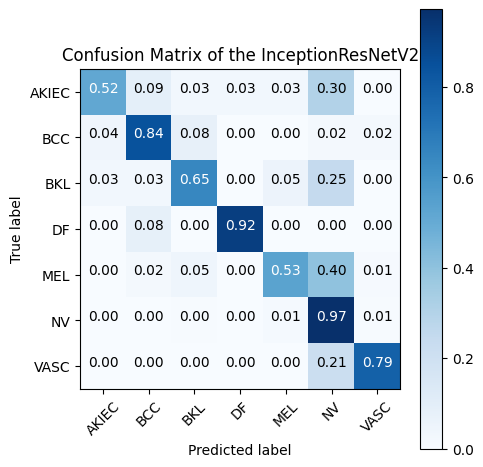

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm_plot_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix of the InceptionResNetV2', normalize=True)